<a href="https://colab.research.google.com/github/Timur228228228/-/blob/main/pandas_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework

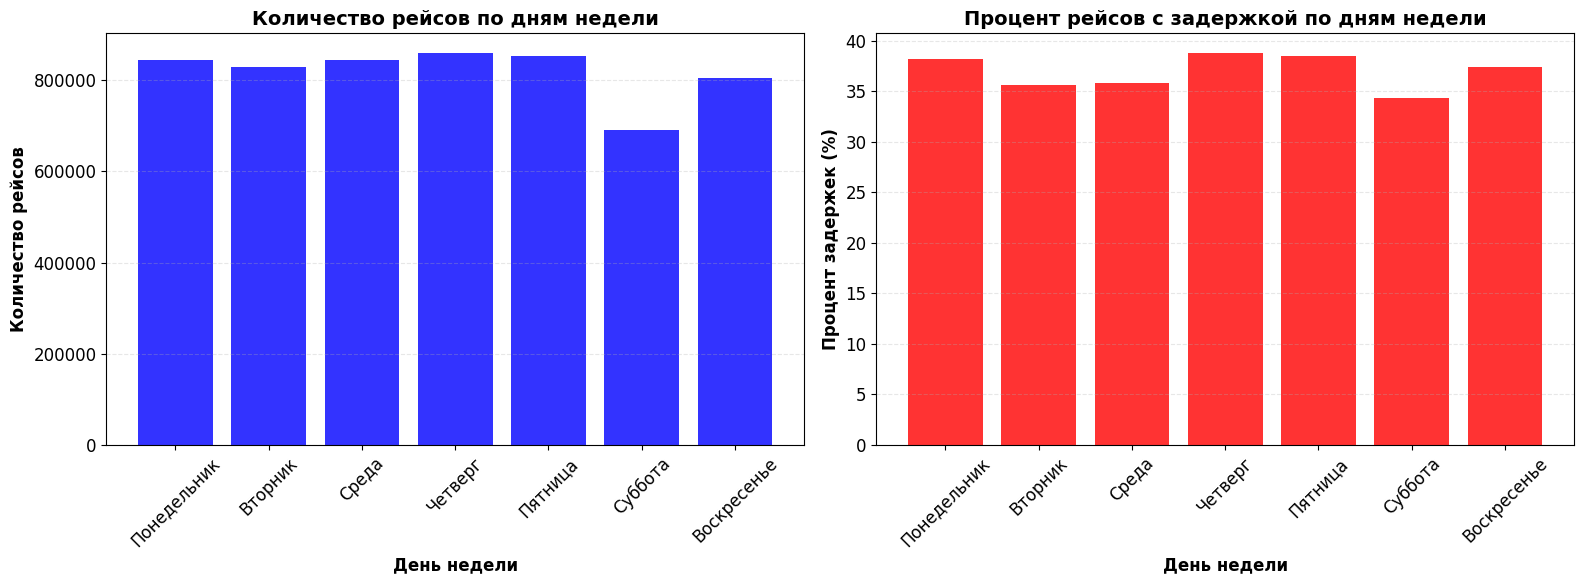

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams


rcParams['figure.figsize'] = (14, 6)
rcParams['font.size'] = 12

df = pd.read_csv('/flights.csv', low_memory=False)
df_airlines = pd.read_csv('/airlines.csv')
df_airports = pd.read_csv('/airports.csv')
df_mask = df[['DEPARTURE_TIME', 'ARRIVAL_TIME']].isna().any(axis=1)
df = df.loc[~df_mask].copy()
df['DEPARTURE_DELAY'] = df['DEPARTURE_DELAY'].astype(float)
df['ARRIVAL_DELAY'] = df['ARRIVAL_DELAY'].astype(float)



day_stats = df.groupby('DAY_OF_WEEK').agg({
    'DEPARTURE_DELAY': ['count', 'mean', 'std', lambda x: (x > 0).sum()],
    'AIRLINE': 'count'
}).round(2)

day_stats.columns = ['total_flights', 'avg_delay', 'std_delay', 'delayed_flights', 'flight_count']
day_stats['delay_percentage'] = (day_stats['delayed_flights'] / day_stats['total_flights'] * 100).round(2)
day_stats = day_stats.reset_index()
day_names = {
    1: 'Понедельник',
    2: 'Вторник',
    3: 'Среда',
    4: 'Четверг',
    5: 'Пятница',
    6: 'Суббота',
    7: 'Воскресенье'
}
day_stats['day_name'] = day_stats['DAY_OF_WEEK'].map(day_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(day_stats['day_name'], day_stats['flight_count'],color='blue', linewidth=1.5, alpha=0.8)
axes[0].set_xlabel('День недели', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Количество рейсов', fontsize=12, fontweight='bold')
axes[0].set_title('Количество рейсов по дням недели', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

axes[1].bar(day_stats['day_name'], day_stats['delay_percentage'],color='red', linewidth=1.5, alpha=0.8)
axes[1].set_xlabel('День недели', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Процент задержек (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Процент рейсов с задержкой по дням недели', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('delays_by_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()


Наименьшее количество рейсов у нас в субботу, причем проседает значение довольно таки сильно. А в четверг у нас самый большой процент по задержкам, те задержка наблюдается у примерно 38% рейсов.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


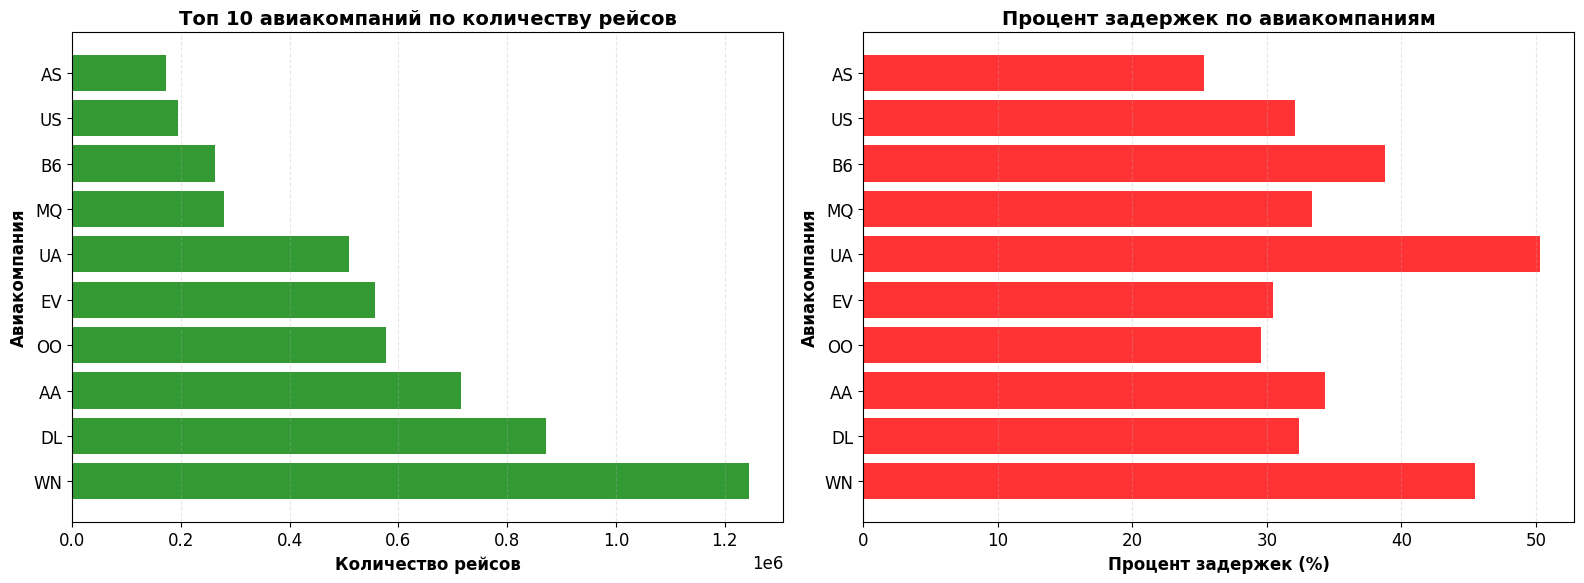

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams


rcParams['figure.figsize'] = (14, 6)
rcParams['font.size'] = 12

df = pd.read_csv('/flights.csv', low_memory=False)
df_airlines = pd.read_csv('/airlines.csv')
df_airports = pd.read_csv('/airports.csv')
df_mask = df[['DEPARTURE_TIME', 'ARRIVAL_TIME']].isna().any(axis=1)
df = df.loc[~df_mask].copy()
df['DEPARTURE_DELAY'] = df['DEPARTURE_DELAY'].astype(float)
df['ARRIVAL_DELAY'] = df['ARRIVAL_DELAY'].astype(float)

df_merged = df.merge(df_airlines, on='AIRLINE', how='left')


airline_stats = df_merged.groupby('AIRLINE').agg({'DEPARTURE_DELAY': ['count', 'mean', 'std', lambda x: (x > 0).sum()],'AIRLINE': 'count'}).round(2)

airline_stats.columns = ['total_flights', 'avg_delay', 'std_delay', 'delayed_flights', 'flight_count']
airline_stats['delay_percentage'] = (airline_stats['delayed_flights'] / airline_stats['flight_count'] * 100).round(2)
airline_stats = airline_stats.reset_index()
airline_stats = airline_stats.merge(df_airlines, on='AIRLINE', how='left')
airline_stats = airline_stats.sort_values('flight_count', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_airlines = airline_stats.nlargest(10, 'flight_count')
axes[0].barh(top_airlines['AIRLINE'], top_airlines['flight_count'], color='green', linewidth=1.5, alpha=0.8)
axes[0].set_xlabel('Количество рейсов', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Авиакомпания', fontsize=12, fontweight='bold')
axes[0].set_title('Топ 10 авиакомпаний по количеству рейсов', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].barh(top_airlines['AIRLINE'], top_airlines['delay_percentage'], color='red', linewidth=1.5, alpha=0.8)
axes[1].set_xlabel('Процент задержек (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Авиакомпания', fontsize=12, fontweight='bold')
axes[1].set_title('Процент задержек по авиакомпаниям', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('airline_delays.png', dpi=150, bbox_inches='tight')
plt.show()

Самое большоше количество рейсов у компании WN- Southwest Airlines, но стоит отметить что у компании United Airlines самый большей процент задержек рейсов.

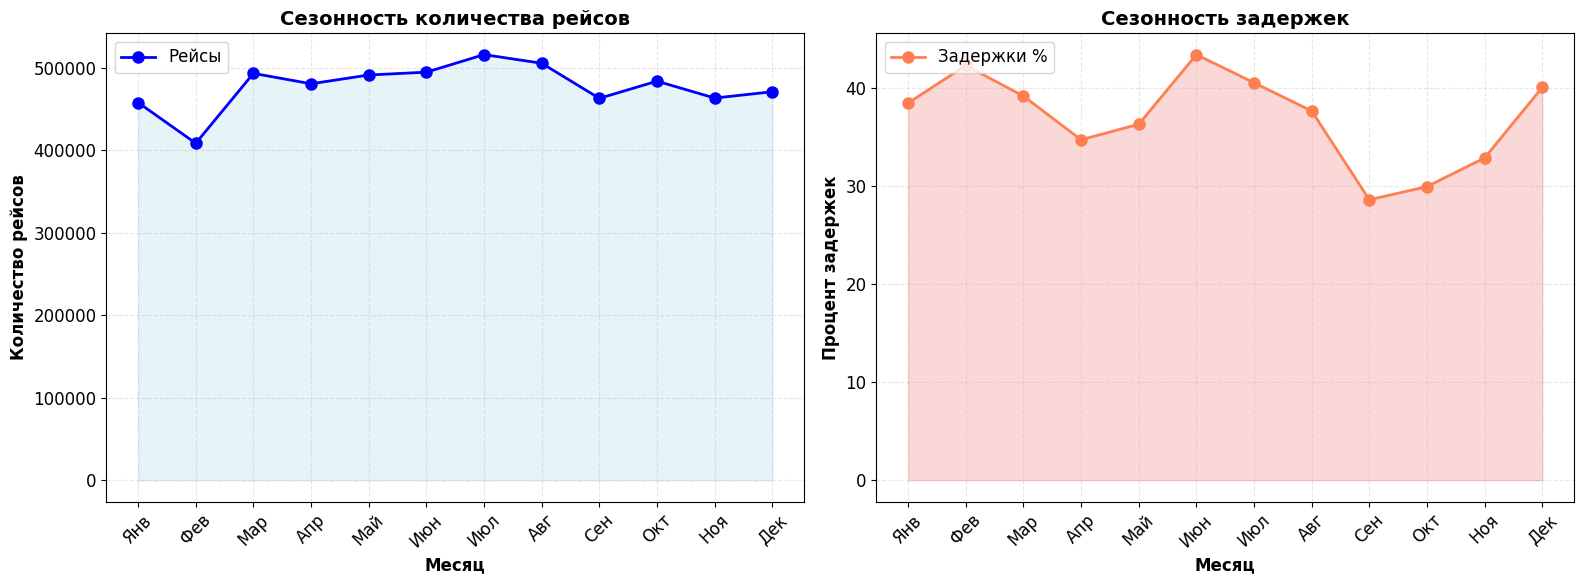

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams


rcParams['figure.figsize'] = (14, 6)
rcParams['font.size'] = 12

df = pd.read_csv('/flights.csv', low_memory=False)
df_airlines = pd.read_csv('/airlines.csv')
df_airports = pd.read_csv('/airports.csv')
df_mask = df[['DEPARTURE_TIME', 'ARRIVAL_TIME']].isna().any(axis=1)
df = df.loc[~df_mask].copy()
df['DEPARTURE_DELAY'] = df['DEPARTURE_DELAY'].astype(float)
df['ARRIVAL_DELAY'] = df['ARRIVAL_DELAY'].astype(float)

month_names = {
    1: 'Янв', 2: 'Фев', 3: 'Мар', 4: 'Апр', 5: 'Май', 6: 'Июн',
    7: 'Июл', 8: 'Авг', 9: 'Сен', 10: 'Окт', 11: 'Ноя', 12: 'Дек'
}
df['MONTH_NAME'] = df['MONTH'].map(month_names)

monthly_stats = df.groupby('MONTH').agg({
    'DEPARTURE_DELAY': ['count', 'mean', 'std', lambda x: (x > 0).sum()]
}).round(2)
monthly_stats.columns = ['total_flights', 'avg_delay', 'std_delay', 'delayed_flights']
monthly_stats['delay_percentage'] = (monthly_stats['delayed_flights'] / monthly_stats['total_flights'] * 100).round(2)
monthly_stats = monthly_stats.reset_index()
monthly_stats['MONTH_NAME'] = monthly_stats['MONTH'].map(month_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(monthly_stats['MONTH_NAME'], monthly_stats['total_flights'], marker='o', linewidth=2, markersize=8, color='blue', label='Рейсы')
axes[0].fill_between(monthly_stats['MONTH_NAME'], monthly_stats['total_flights'], alpha=0.3, color='lightblue')
axes[0].set_xlabel('Месяц', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Количество рейсов', fontsize=12, fontweight='bold')
axes[0].set_title('Сезонность количества рейсов', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='upper left')

axes[1].plot(monthly_stats['MONTH_NAME'], monthly_stats['delay_percentage'], marker='o', linewidth=2, markersize=8, color='coral', label='Задержки %')
axes[1].fill_between(monthly_stats['MONTH_NAME'], monthly_stats['delay_percentage'], alpha=0.3, color='lightcoral')
axes[1].set_xlabel('Месяц', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Процент задержек', fontsize=12, fontweight='bold')
axes[1].set_title('Сезонность задержек', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.savefig('seasonal_delays.png', dpi=150, bbox_inches='tight')
plt.show()

в феврале проседает количество рейсов, а в сентябре самый маленький процент задержек, а в июне самый большой